In [1]:
import os, yaml, sys
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder

ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
from general_utils.utils import decode_matlab_strings, load_img_natraster, TimeSeries, dRSA, get_relevant_output_layers, BrainAreas
from general_utils.II import dynInformationImbalance
from image_processing.computational_models import map_image_order_from_ann_to_monkey


In [57]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    monkey_name: str = 'baby1'
    date: str =  '220226to527'
    img_size = 384
    ks = [1, 10, 50, 100, 200, 500]
    folder_name = 'talia_20each_tizi' # 'fewer_occlusion'
    new_fs = 100
    RDM_metric_signal = 'cosine_cnt'
    RDM_metric_model = 'cosine_cnt'
    RSA_metric = 'correlation'
    brain_area = "AIT"
    model_name = 'vit_l_16'
    pkg = 'timm'
    img_size = 384
    pooling = 'mean'
    layer_name = 'blocks.1.mlp.fc2'
cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, cfg.pkg)

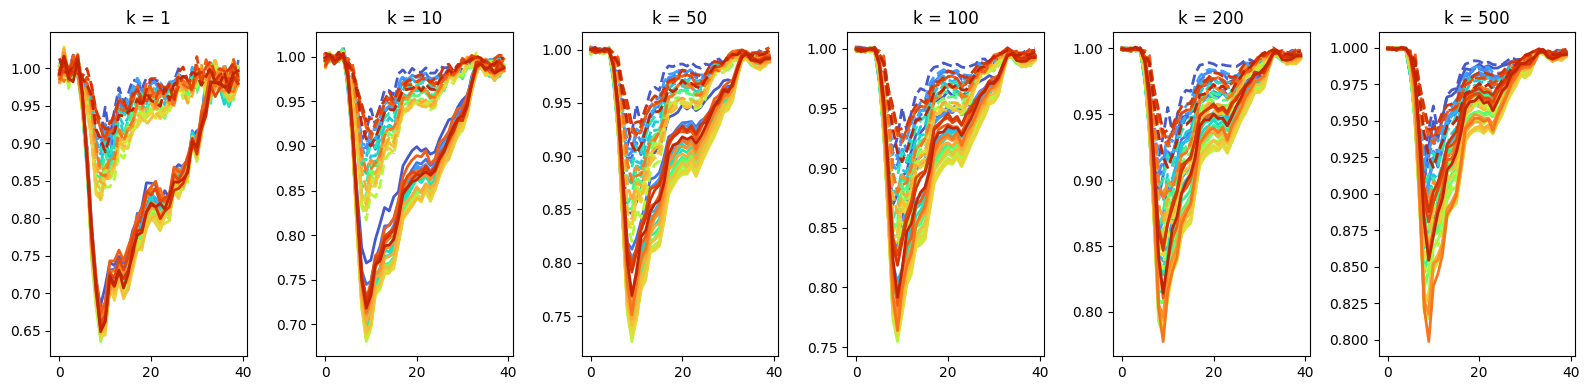

In [ ]:
from general_utils.plots import truncate_colormap
base_cmap = plt.cm.turbo

cmap = truncate_colormap(base_cmap, 0.10, 0.90)
fig, ax = plt.subplots(1,len(cfg.ks), figsize=(16, 4))
for idx_k, k in enumerate(cfg.ks):
    for i_col, l in enumerate(layers):
        color = cmap(i_col / (len(layers) - 1))
        try:
            A2B_fn = f"{paths['livingstone_lab']}/tiziano/results/dynII_A2B_k{k}_{cfg.RDM_metric_signal}-{cfg.RDM_metric_model}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
            B2A_fn = f"{paths['livingstone_lab']}/tiziano/results/dynII_B2A_k{k}_{cfg.RDM_metric_signal}-{cfg.RDM_metric_model}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
            A2B = np.load(A2B_fn)["arr_0"]
            B2A = np.load(B2A_fn)["arr_0"]
            if k == cfg.ks[-1]:
                ax[idx_k].plot(A2B, color=color, linewidth=2, label=l, linestyle="--")
                ax[idx_k].plot(B2A, color=color, label=l, linewidth=2)
            else:
                ax[idx_k].plot(A2B, color=color, linewidth=2, linestyle="--")
                ax[idx_k].plot(B2A, color=color, linewidth=2)
            
            ax[idx_k].set_title(f"k = {k}")
            # ax[idx_k].set_ylim([1, .6])
        except FileNotFoundError:
            print(f"failed to load {A2B_fn}")
            pass
    
# fig.legend(
#     loc="center left",
#     bbox_to_anchor=(1.02, 0.5),
#     frameon=False
# );
plt.tight_layout()

In [41]:
RSA_fn = f"{paths['livingstone_lab']}/tiziano/results/static_dRSA_{cfg.RDM_metric_signal}-{cfg.RDM_metric_model}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
np.max(np.load(RSA_fn)["arr_0"])

0.11503080478728135

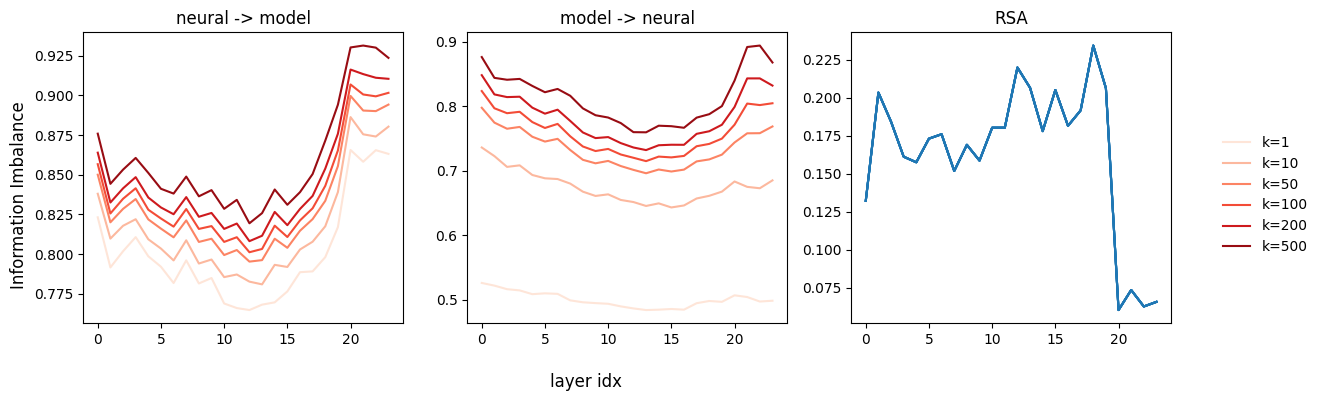

In [58]:
from general_utils.plots import truncate_colormap
base_cmap = plt.cm.Reds

cmap = truncate_colormap(base_cmap, 0.10, 0.90)
fig, ax = plt.subplots(1,3, figsize=(12, 4))
for idx_k, k in enumerate(cfg.ks):
    A2B_tot = []
    B2A_tot = []
    RSA_tot = []
    color = cmap(idx_k / (len(cfg.ks) - 1))
    for l in layers:
        A2B_fn = f"{paths['livingstone_lab']}/tiziano/results/dynII_A2B_k{k}_{cfg.RDM_metric_signal}-{cfg.RDM_metric_model}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
        B2A_fn = f"{paths['livingstone_lab']}/tiziano/results/dynII_B2A_k{k}_{cfg.RDM_metric_signal}-{cfg.RDM_metric_model}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
        RSA_fn = f"{paths['livingstone_lab']}/tiziano/results/static_dRSA_{cfg.RDM_metric_signal}-{cfg.RDM_metric_model}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
        A2B = np.min(np.load(A2B_fn)["arr_0"])
        B2A = np.min(np.load(B2A_fn)["arr_0"])
        RSA = np.max(np.load(RSA_fn)["arr_0"])
        A2B_tot.append(A2B)
        B2A_tot.append(B2A)
        RSA_tot.append(RSA)
    ax[0].plot(A2B_tot, color=color, label=f"k={k}")
    ax[1].plot(B2A_tot, color=color,)
    ax[2].plot(RSA_tot, color="tab:blue",)
fig.supylabel("Information Imbalance")
fig.supxlabel("layer idx")
ax[0].set_title("neural -> model")
ax[1].set_title("model -> neural")
ax[2].set_title("RSA")

fig.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
);
plt.tight_layout()

In [59]:
np.corrcoef(A2B_tot, RSA_tot)

array([[ 1.        , -0.81077005],
       [-0.81077005,  1.        ]])